In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pickle
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
with open('maze2_recon.pkl', 'rb') as f:
    maze2_recon = pickle.load(f)
with open("loc_vecs.pkl", "rb") as f:
    loc_vecs = pickle.load(f)

In [3]:
def to_day(di):
    if di >= 2:
        return "day6"
    else:
        return "day" + str(di + 1)

mouse1, day1, Seq-#1


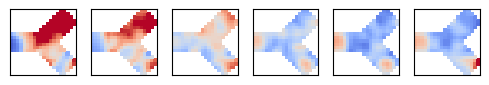

mouse1, day1, Seq-#2


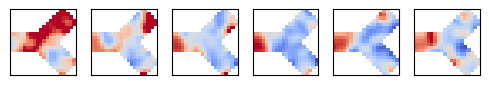

mouse1, day1, Seq-#3


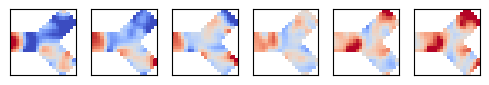

mouse1, day1, Seq-#4


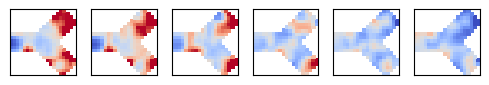

mouse1, day1, Seq-#5


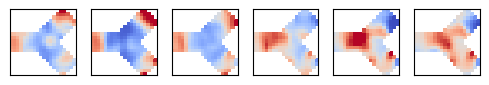

mouse1, day1, Seq-#6


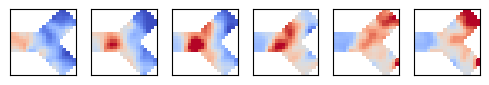

mouse1, day2, Seq-#1


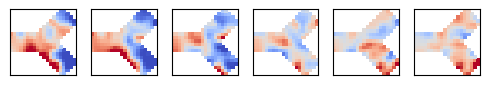

mouse1, day2, Seq-#2


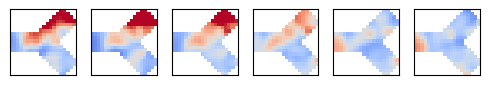

mouse1, day2, Seq-#3


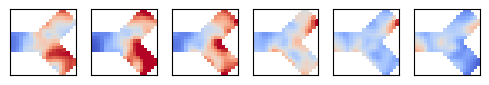

mouse1, day2, Seq-#4


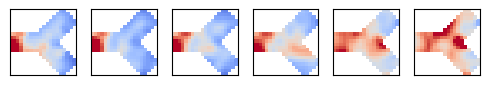

mouse1, day6, Seq-#1


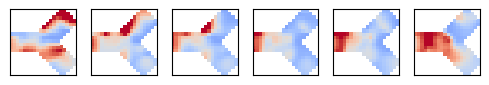

mouse1, day6, Seq-#2


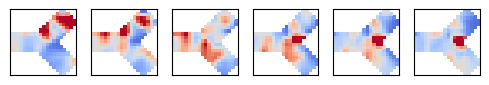

mouse1, day6, Seq-#3


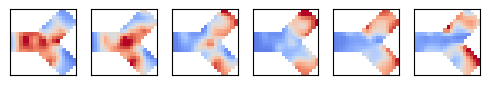

mouse1, day6, Seq-#4


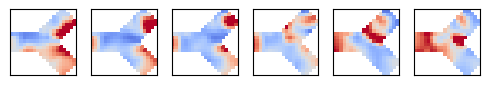

mouse1, day6, Seq-#5


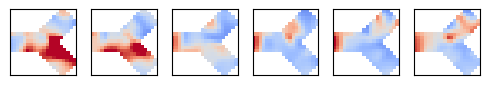

mouse2, day1, Seq-#1


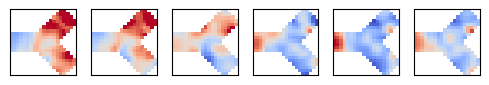

mouse2, day1, Seq-#2


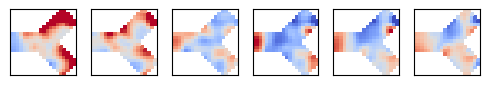

mouse2, day1, Seq-#3


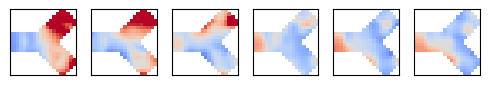

mouse2, day1, Seq-#4


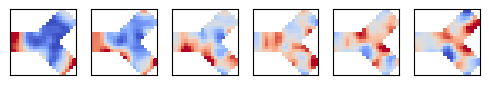

mouse2, day1, Seq-#5


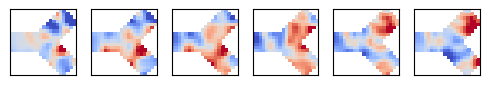

mouse2, day1, Seq-#6


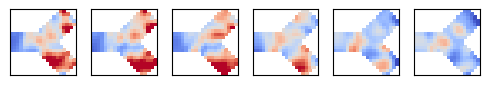

mouse2, day1, Seq-#7


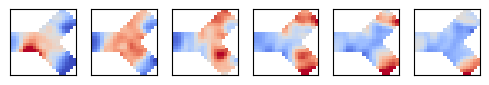

mouse2, day1, Seq-#8


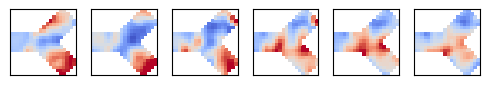

mouse2, day1, Seq-#9


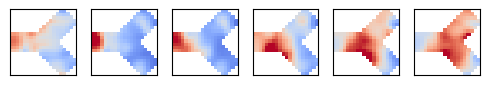

mouse2, day2, Seq-#1


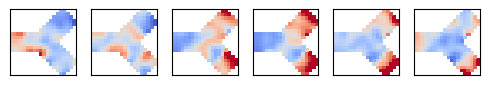

mouse2, day2, Seq-#2


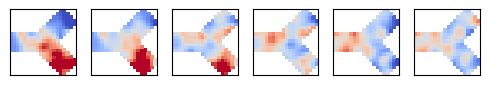

mouse2, day2, Seq-#3


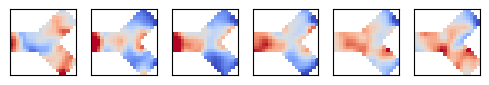

mouse2, day2, Seq-#4


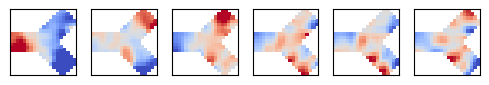

mouse2, day2, Seq-#5


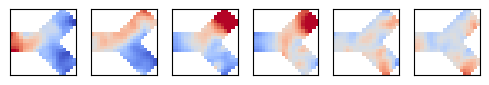

mouse2, day2, Seq-#6


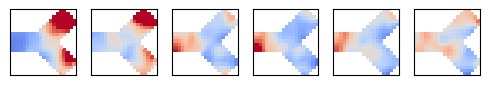

mouse2, day2, Seq-#7


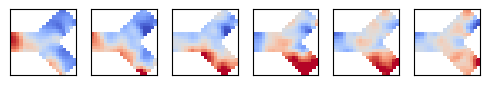

mouse2, day2, Seq-#8


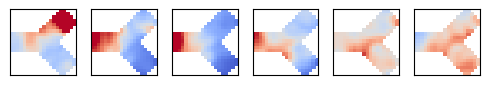

mouse2, day2, Seq-#9


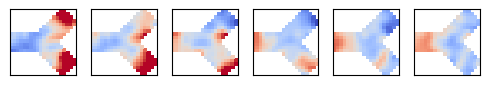

mouse2, day2, Seq-#10


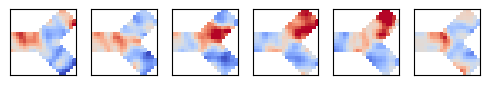

mouse2, day6, Seq-#1


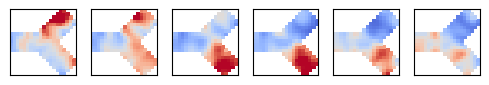

mouse2, day6, Seq-#2


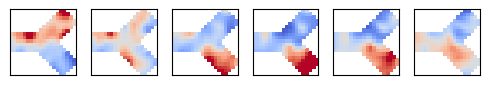

mouse2, day6, Seq-#3


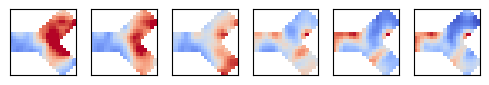

mouse2, day6, Seq-#4


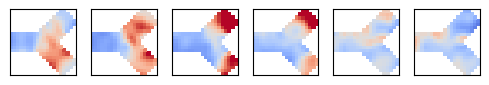

mouse2, day6, Seq-#5


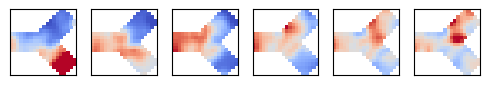

mouse2, day6, Seq-#6


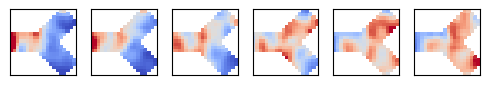

mouse2, day6, Seq-#7


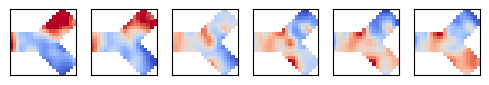

mouse2, day6, Seq-#8


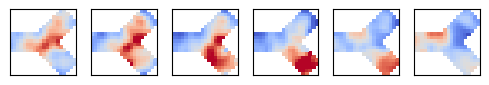

mouse3, day1, Seq-#1


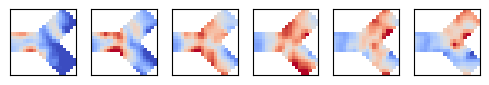

mouse3, day1, Seq-#2


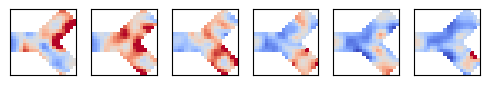

mouse3, day1, Seq-#3


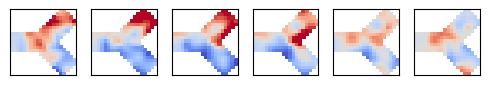

mouse3, day1, Seq-#4


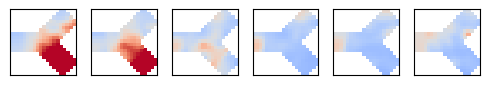

mouse3, day1, Seq-#5


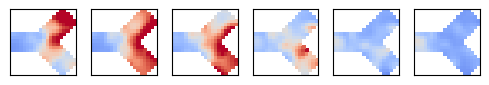

mouse3, day1, Seq-#6


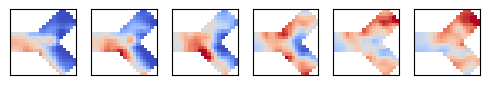

mouse3, day1, Seq-#7


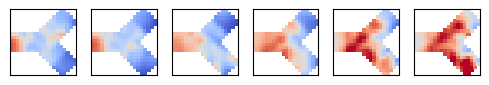

mouse3, day2, Seq-#1


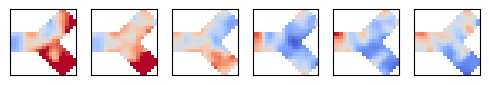

mouse3, day2, Seq-#2


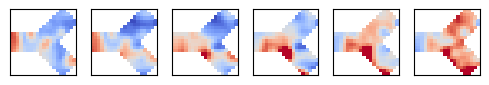

mouse3, day2, Seq-#3


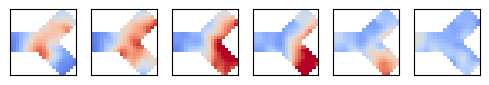

mouse3, day2, Seq-#4


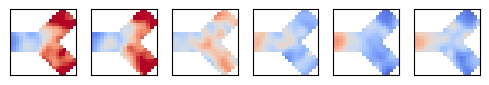

mouse3, day2, Seq-#5


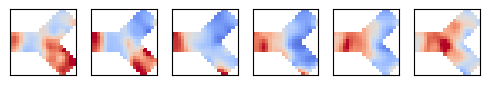

mouse3, day2, Seq-#6


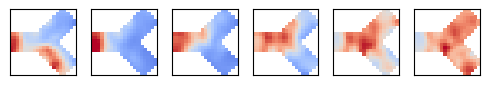

mouse3, day2, Seq-#7


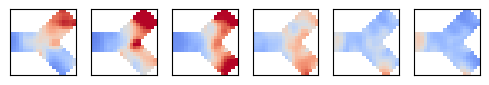

mouse3, day6, Seq-#1


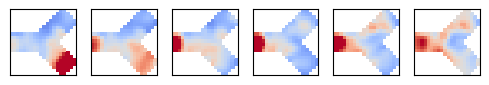

mouse3, day6, Seq-#2


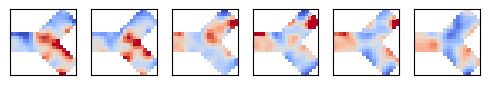

mouse3, day6, Seq-#3


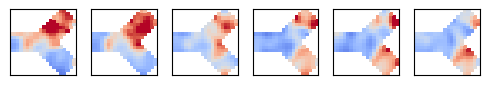

mouse3, day6, Seq-#4


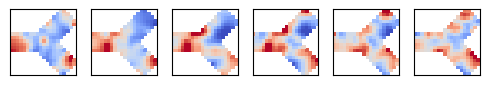

mouse3, day6, Seq-#5


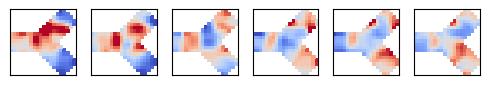

mouse3, day6, Seq-#6


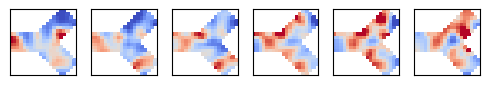

mouse3, day6, Seq-#7


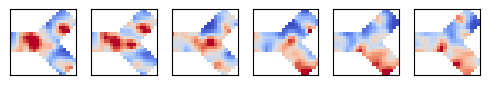

mouse3, day6, Seq-#8


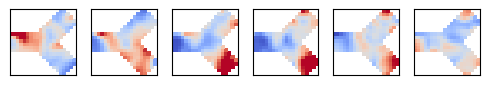

mouse4, day1, Seq-#1


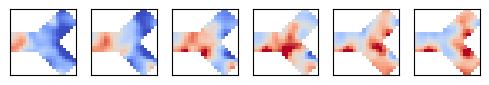

mouse4, day1, Seq-#2


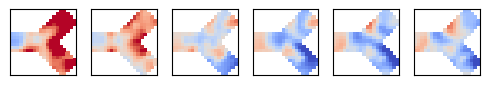

mouse4, day1, Seq-#3


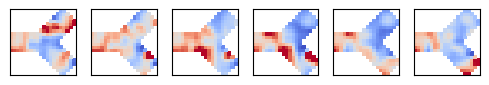

mouse4, day1, Seq-#4


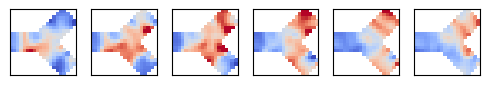

mouse4, day1, Seq-#5


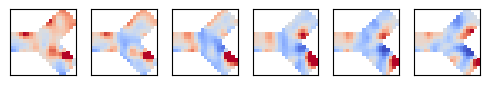

mouse4, day1, Seq-#6


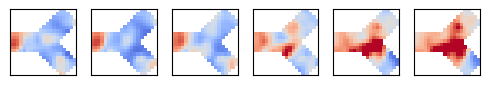

mouse4, day1, Seq-#7


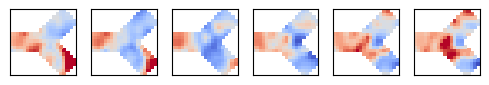

mouse4, day2, Seq-#1


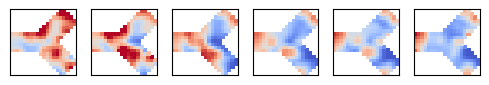

mouse4, day2, Seq-#2


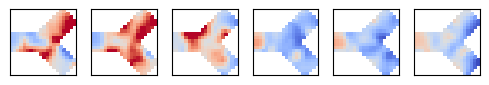

mouse4, day2, Seq-#3


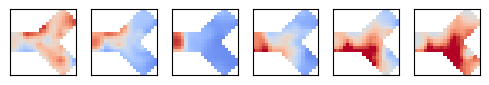

mouse4, day2, Seq-#4


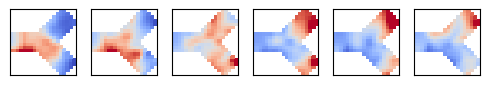

mouse4, day2, Seq-#5


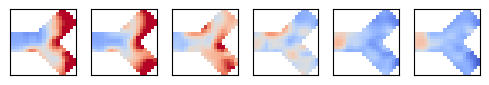

mouse4, day2, Seq-#6


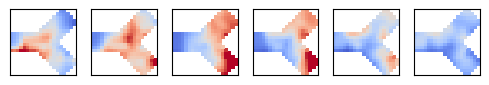

mouse4, day6, Seq-#1


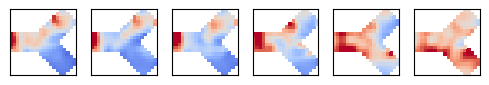

mouse4, day6, Seq-#2


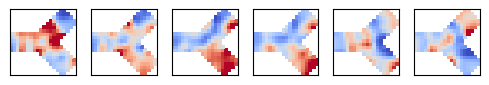

mouse4, day6, Seq-#3


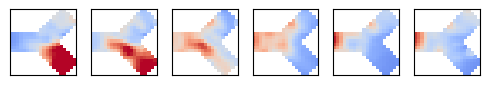

mouse4, day6, Seq-#4


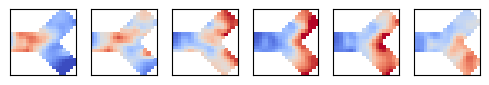

mouse4, day6, Seq-#5


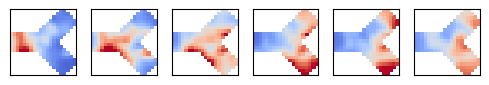

mouse4, day6, Seq-#6


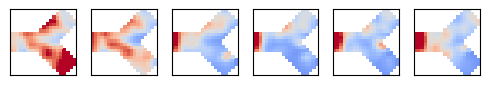

mouse4, day6, Seq-#7


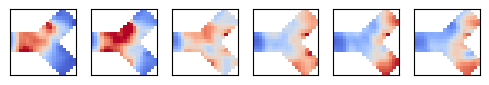

mouse5, day1, Seq-#1


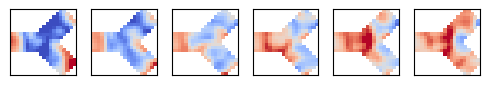

mouse5, day1, Seq-#2


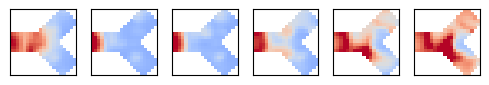

mouse5, day1, Seq-#3


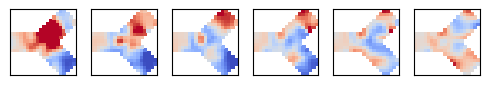

mouse5, day1, Seq-#4


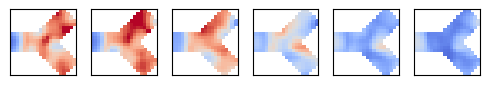

mouse5, day1, Seq-#5


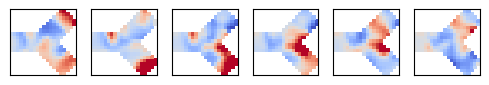

mouse5, day2, Seq-#1


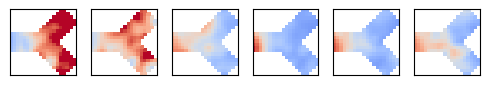

mouse5, day2, Seq-#2


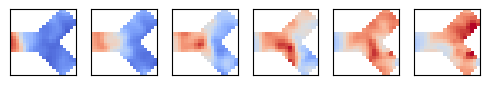

mouse5, day2, Seq-#3


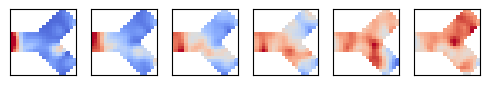

mouse5, day2, Seq-#4


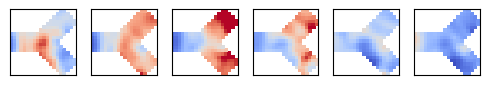

mouse5, day2, Seq-#5


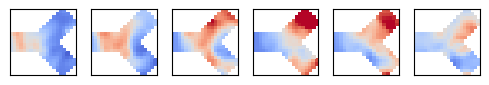

mouse5, day2, Seq-#6


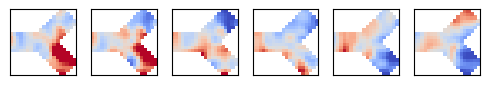

mouse5, day6, Seq-#1


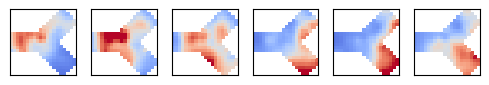

mouse5, day6, Seq-#2


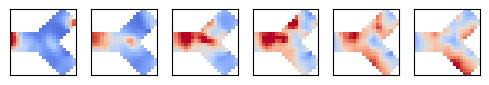

mouse5, day6, Seq-#3


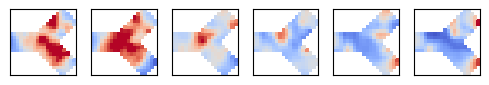

mouse5, day6, Seq-#4


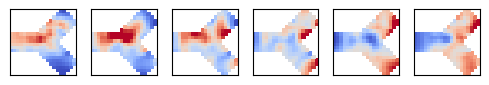

mouse5, day6, Seq-#5


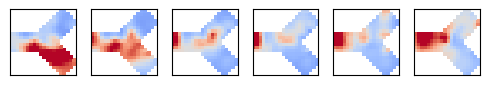

mouse6, day1, Seq-#1


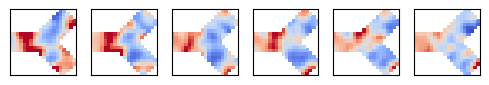

mouse6, day1, Seq-#2


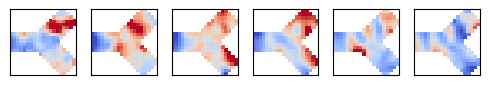

mouse6, day1, Seq-#3


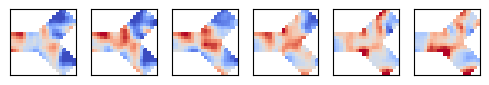

mouse6, day1, Seq-#4


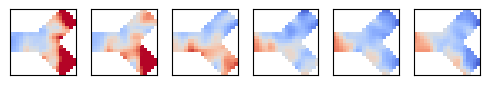

mouse6, day1, Seq-#5


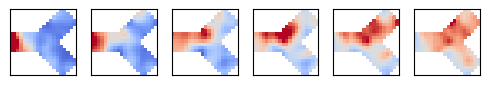

mouse6, day2, Seq-#1


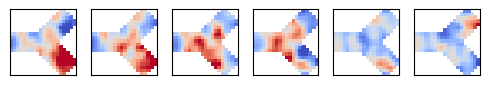

mouse6, day2, Seq-#2


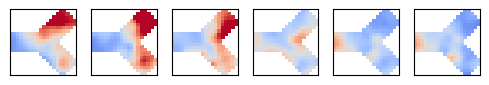

mouse6, day2, Seq-#3


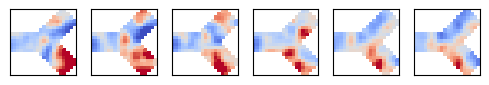

mouse6, day2, Seq-#4


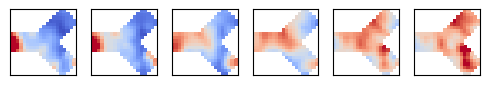

mouse6, day2, Seq-#5


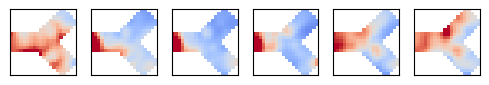

mouse6, day6, Seq-#1


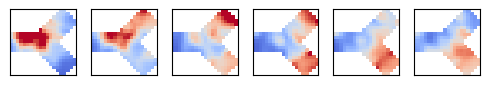

mouse6, day6, Seq-#2


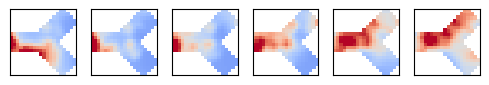

mouse6, day6, Seq-#3


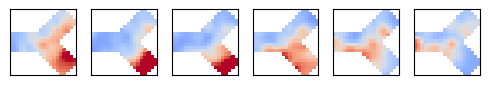

mouse6, day6, Seq-#4


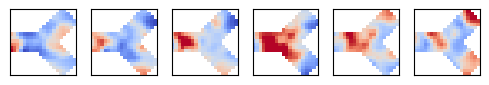

In [4]:
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    for di in range(3):
        day = to_day(di)
        lv = loc_vecs[mi][di]
        k = lv.shape[0]
        lv_flat = lv.reshape(k, -1)
        lv = (lv - lv_flat.mean(axis=-1).reshape(-1, 1, 1)) / lv_flat.std(axis=-1).reshape(-1, 1, 1)
        for ki in range(k):
            print("{}, {}, Seq-#{}".format(mouse, day, ki+1))
            tmp = np.zeros((6, 20, 20))
            tmp[:, :, :] = np.nan
            for (y, x), val in zip(maze2_recon, lv[ki, [0, 10, 20, 30, 40, 49], :].T):
                tmp[:, y, x] = val
            fig, axes = plt.subplots(1, 6, figsize=(5, 1))
            for ti in range(6):
                axes[ti].tick_params(labelleft=False, labelbottom=False, left=False, bottom=False)
                axes[ti].pcolor(tmp[ti, :, :].T, vmin=-2, vmax=2, cmap="coolwarm")
                axes[ti].set_aspect("equal")
            plt.tight_layout()
            plt.savefig("figures/fig4/fig4c/fig4c_{}_{}_seq{}.png".format(mouse, day, ki+1))
            plt.show()

In [5]:
gini = []
for mi in range(6):
    gini_s = []
    for di in range(3):
        s = np.array([np.abs(loc_vecs[mi][di][:, :, i] - loc_vecs[mi][di][:, :, j]) for i in range(190) for j in range(190)]).sum(axis=0)
        gini_s.append((s / (2 * 190**2 * loc_vecs[mi][di].mean(axis=-1))).mean(axis=1))
    gini.append(gini_s)

In [6]:
gini_mean = np.array([[gini[mi][di].mean() for di in range(3)] for mi in range(6)])

day1: 0.2123 ± 0.0126
day2: 0.2395 ± 0.0091
day6: 0.2875 ± 0.0208


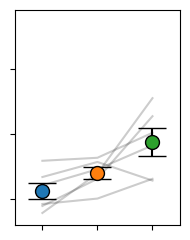

In [7]:
plt.figure(figsize=(2, 2.5))
plt.plot(gini_mean.T, color="k", alpha=0.2)
for di in range(3):
    y = gini_mean[:, di].mean()
    yerr = stats.sem(gini_mean[:, di])
    print("{}: {:.4f} ± {:.4f}".format(to_day(di), y, yerr))
    plt.errorbar(di, y=y, fmt="o", yerr=yerr, ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10)
plt.xlim(-0.5, 2.5)
plt.ylim(0.16, 0.49)
plt.xticks([0, 1, 2])
plt.yticks([0.2, 0.3, 0.4])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig4/fig4e.png")
plt.show()

In [8]:
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "gini": np.array(gini_mean).T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6),
})
print(AnovaRM(data=df, depvar="gini", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df['gini'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  6.7609 2.0000 10.0000 0.0139

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  day1   day2   0.0272 0.4267 -0.0279 0.0822  False
  day1   day6   0.0752 0.0077  0.0202 0.1303   True
  day2   day6   0.0481  0.092  -0.007 0.1031  False
---------------------------------------------------
